In [1]:
import torch

print("CUDA disponible :", torch.cuda.is_available())
print("GPU :", torch.cuda.get_device_name(0))
print("VRAM (GB) :", torch.cuda.get_device_properties(0).total_memory / 1e9)


CUDA disponible : True
GPU : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM (GB) : 8.19625984


In [12]:
# @title
# import shutil
# from pathlib import Path
# from collections import defaultdict
# import random

# def redistribute_dataset(dataset_path, train_ratio=0.7, valid_ratio=0.2, test_ratio=0.1):
#     """
#     Redistribuer le dataset pour équilibrer les classes dans tous les splits
#     """
#     dataset_path = Path(dataset_path)

#     # Classes à redistribuer (mask=2, safety_boots=4)
#     target_classes = [2, 4]

#     print("🔄 Redistribution des classes mask et safety_boots...")

#     # Trouver toutes les images contenant mask ou safety_boots dans train
#     train_labels = dataset_path / 'train' / 'labels'
#     images_to_redistribute = defaultdict(list)

#     for label_file in train_labels.glob('*.txt'):
#         with open(label_file) as f:
#             content = f.read()
#             for target_class in target_classes:
#                 if f"{target_class} " in content:
#                     images_to_redistribute[target_class].append(label_file.stem)
#                     break  # Une seule fois par image

#     print(f"\n📊 Images trouvées:")
#     for cls_id, images in images_to_redistribute.items():
#         class_name = ['glass', 'hardhat', 'mask', 'person', 'safety_boots', 'vest'][cls_id]
#         print(f"  {class_name}: {len(images)} images")

#     # Redistribuer chaque classe
#     for cls_id, image_list in images_to_redistribute.items():
#         class_name = ['glass', 'hardhat', 'mask', 'person', 'safety_boots', 'vest'][cls_id]
#         print(f"\n🔀 Redistribution de {class_name}...")

#         # Mélanger
#         random.shuffle(image_list)

#         # Calculer les splits
#         total = len(image_list)
#         train_count = int(total * train_ratio)
#         valid_count = int(total * valid_ratio)

#         train_images = image_list[:train_count]
#         valid_images = image_list[train_count:train_count + valid_count]
#         test_images = image_list[train_count + valid_count:]

#         print(f"  Train: {len(train_images)}")
#         print(f"  Valid: {len(valid_images)} (à déplacer)")
#         print(f"  Test: {len(test_images)} (à déplacer)")

#         # Déplacer vers valid
#         for img_name in valid_images:
#             # Déplacer image
#             for ext in ['.jpg', '.png', '.jpeg']:
#                 src_img = dataset_path / 'train' / 'images' / f"{img_name}{ext}"
#                 if src_img.exists():
#                     dst_img = dataset_path / 'valid' / 'images' / f"{img_name}{ext}"
#                     shutil.move(str(src_img), str(dst_img))
#                     break

#             # Déplacer label
#             src_label = dataset_path / 'train' / 'labels' / f"{img_name}.txt"
#             dst_label = dataset_path / 'valid' / 'labels' / f"{img_name}.txt"
#             if src_label.exists():
#                 shutil.move(str(src_label), str(dst_label))

#         # Déplacer vers test
#         for img_name in test_images:
#             # Déplacer image
#             for ext in ['.jpg', '.png', '.jpeg']:
#                 src_img = dataset_path / 'train' / 'images' / f"{img_name}{ext}"
#                 if src_img.exists():
#                     dst_img = dataset_path / 'test' / 'images' / f"{img_name}{ext}"
#                     dst_img.parent.mkdir(parents=True, exist_ok=True)
#                     shutil.move(str(src_img), str(dst_img))
#                     break

#             # Déplacer label
#             src_label = dataset_path / 'train' / 'labels' / f"{img_name}.txt"
#             dst_label = dataset_path / 'test' / 'labels' / f"{img_name}.txt"
#             dst_label.parent.mkdir(parents=True, exist_ok=True)
#             if src_label.exists():
#                 shutil.move(str(src_label), str(dst_label))

#     print("\n✅ Redistribution terminée!")
#     print("\n⚠️  IMPORTANT: Vérifiez les chemins dans data.yaml")

# # Utilisation
# redistribute_dataset(
#     "/content/drive/MyDrive/PFE-2026/Projet/V3/dataset",
#     train_ratio=0.7,
#     valid_ratio=0.2,
#     test_ratio=0.1
# )

# SECTION 1: INSTALLATION ET IMPORTS

In [6]:

import os
import shutil
import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from IPython.display import display, Image
import json

print("=========== Installation des packages nécessaires...============")



# Imports après installation
from ultralytics import YOLO, RTDETR
import torch

print(f"**********Installation terminée! ************")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Mémoire GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")



=========== Installation des packages nécessaires...============
**********Installation terminée! ************
PyTorch version: 2.5.1+cu121
CUDA disponible: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Mémoire GPU: 8.20 GB


# SECTION 2: CONFIGURATION DU PROJET

In [ ]:
from pathlib import Path
import shutil
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from IPython.display import display, Image
import torch
from ultralytics import YOLO, RTDETR

# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    """Configuration centralisée du projet"""

    #
    DATA_YAML = "dataset/data.yaml"

    # Chemins de travail
    BASE_DIR ="../runs"
    RESULTS_DIR = BASE_DIR / "results"
    MODELS_DIR =  BASE_DIR / "models"



    # Paramètres d'entraînement
    EPOCHS = 100
    BATCH_SIZE = 16
    IMG_SIZE = 640
    PATIENCE = 20

    # Modèles à entraîner
    MODELS = {
       'YOLOv11s': 'yolo11s.pt',
        'YOLOv11m': 'yolo11m.pt',
        'YOLO26s': 'yolo26s.pt',
        'YOLO26n': 'yolo26n.pt',
        'YOLO26m': 'yolo26m.pt',
    }

    @classmethod
    def setup_directories(cls):
        """Créer les répertoires nécessaires"""
        for dir_path in [cls.RESULTS_DIR, cls.MODELS_DIR]:
            dir_path.mkdir(parents=True, exist_ok=True)
        print(f" Répertoires créés: {cls.RESULTS_DIR}, {cls.MODELS_DIR}")

# Initialisation
Config.setup_directories()

# ============================================================================
# VÉRIFICATION DU DATASET
# ============================================================================

print(" Vérification du dataset...")

if Path(Config.DATA_YAML).exists():
    print(f" Dataset trouvé: {Config.DATA_YAML}")

    with open(Config.DATA_YAML, 'r') as f:
        data_config = yaml.safe_load(f)

    print(f"\n Configuration:")
    print(f"    Classes: {data_config['names']}")
    print(f"    Nombre: {data_config['nc']}")
    print(f"    Prêt pour l'entraînement ")

    data_yaml_path = Config.DATA_YAML

else:
    print(f" Dataset non trouvé!")
    print(f" Chemin recherché: {Config.DATA_YAML}")
    data_yaml_path = None


AttributeError: 'str' object has no attribute 'mkdir'

# SECTION 4: FONCTIONS D'ENTRAÎNEMENT

In [15]:

def train_model(model_name, model_path, data_yaml):
    """
    Entraîner un modèle avec les meilleurs hyperparamètres

    Args:
        model_name: Nom du modèle pour l'identification
        model_path: Chemin vers le modèle pré-entraîné
        data_yaml: Chemin vers le fichier de configuration des données

    Returns:
        Dictionnaire avec les résultats et métriques
    """
    print(f"\n{'='*70}")
    print(f" Entraînement du modèle: {model_name}")
    print(f"{'='*70}")

    start_time = datetime.datetime.now()

    try:
        # Initialiser le modèle
        if 'rtdetr' in model_name.lower():
            model = RTDETR(model_path)
        else:
            model = YOLO(model_path)

        # Paramètres d'entraînement optimisés
        training_args = {
            'data': data_yaml,
            'epochs': Config.EPOCHS,
            'imgsz': Config.IMG_SIZE,
            'batch': Config.BATCH_SIZE,
            'patience': Config.PATIENCE,
            'save': True,
            'device': 0 if torch.cuda.is_available() else 'cpu',
            'workers': 8,
            'project': str(Config.RESULTS_DIR),
            'name': model_name,
            'exist_ok': True,

            # Augmentation de données
            'hsv_h':0.03,
            'hsv_s':0.9,
            'hsv_v':0.5,
            'degrees':20.0,
            'translate':0.2,
            'scale':0.5,
            'shear':5.0,
            'flipud':0.5,
            'fliplr':0.5,
            'mosaic':1.0,
            'mixup':0.15,  # Mélanger les images
            'copy_paste':0.3,  # Copier-coller les objets rares

            # Optimisations
            'optimizer': 'AdamW',
            'lr0': 0.001,
            'lrf': 0.01,
            'momentum': 0.937,
            'weight_decay': 0.0005,
            'warmup_epochs': 3.0,
            'warmup_momentum': 0.8,
            'warmup_bias_lr': 0.1,
            'box': 7.5,
            'cls': 0.5,
            'dfl': 1.5,

            # Autres
            'verbose': True,
            'seed': 42,
            'deterministic': True,
            'single_cls': False,
            'rect': False,
            'cos_lr': False,
            'close_mosaic': 10,
            'amp': True,  # Mixed precision training
            'fraction': 1.0,
            'profile': False,
            'freeze': None,
        }

        # Entraînement
        results = model.train(**training_args)

        # Validation
        print(f"\n Validation du modèle {model_name}...")
        val_results = model.val(
            conf = 0.3
        )

        # Calcul du temps d'entraînement
        end_time = datetime.datetime.now()
        training_duration = (end_time - start_time).total_seconds() / 60

        # Extraction des métriques
        metrics = {
            'model_name': model_name,
            'training_time_minutes': round(training_duration, 2),
            'mAP50': round(val_results.box.map50, 4) if hasattr(val_results, 'box') else 0,
            'mAP50-95': round(val_results.box.map, 4) if hasattr(val_results, 'box') else 0,
            'precision': round(val_results.box.p[0], 4) if hasattr(val_results, 'box') else 0,
            'recall': round(val_results.box.r[0], 4) if hasattr(val_results, 'box') else 0,
            'f1_score': round(2 * (val_results.box.p[0] * val_results.box.r[0]) / (val_results.box.p[0] + val_results.box.r[0]), 4) if hasattr(val_results, 'box') else 0,
            'best_weights': str(Config.RESULTS_DIR / model_name / 'weights' / 'best.pt'),
            'status': 'success'
        }

        print(f"\n {model_name} entraîné avec succès!")
        print(f"  Durée: {training_duration:.2f} minutes")
        print(f" mAP50: {metrics['mAP50']:.4f}")
        print(f" mAP50-95: {metrics['mAP50-95']:.4f}")

        # Sauvegarder le meilleur modèle
        best_model_path = Config.MODELS_DIR / f"{model_name}_best.pt"
        shutil.copy(metrics['best_weights'], best_model_path)
        print(f" Modèle sauvegardé: {best_model_path}")

        return metrics

    except Exception as e:
        print(f" Erreur lors de l'entraînement de {model_name}: {e}")
        return {
            'model_name': model_name,
            'status': 'failed',
            'error': str(e)
        }



# SECTION 5: ENTRAÎNEMENT DE TOUS LES MODÈLES

In [16]:
def train_all_models(data_yaml):
    """Entraîner tous les modèles configurés"""
    print("\n" + "="*70)
    print(" ========= DÉBUT DE L'ENTRAÎNEMENT DE TOUS LES MODÈLES=======")
    print("="*70)

    all_results = []

    for model_name, model_path in Config.MODELS.items():
        result = train_model(model_name, model_path, data_yaml)
        all_results.append(result)

        # Petit break entre les modèles pour libérer la mémoire GPU
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return all_results

# SECTION 6: BENCHMARK ET VISUALISATION

In [17]:
def create_benchmark_report(results):
    """Créer un rapport de benchmark complet"""
    print("\n" + "="*70)
    print("*** GÉNÉRATION DU RAPPORT DE BENCHMARK")
    print("="*70)

    # Filtrer les résultats réussis
    successful_results = [r for r in results if r.get('status') == 'success']

    if not successful_results:
        print("=== Aucun modèle n'a été entraîné avec succès! ===")
        return

    # Créer un DataFrame
    df = pd.DataFrame(successful_results)

    # Trier par mAP50-95 (meilleure métrique globale)
    df_sorted = df.sort_values('mAP50-95', ascending=False)

    # Afficher le tableau
    print("\=== RÉSULTATS COMPARATIFS:===")
    print(df_sorted.to_string(index=False))

    # Identifier le meilleur modèle
    best_model = df_sorted.iloc[0]
    print(f"\n=== MEILLEUR MODÈLE: {best_model['model_name']}===")
    print(f"   ** mAP50-95: {best_model['mAP50-95']:.4f}")
    print(f"   ** mAP50: {best_model['mAP50']:.4f}")
    print(f"   ** Precision: {best_model['precision']:.4f}")
    print(f"   ** Recall: {best_model['recall']:.4f}")
    print(f"   ** F1-Score: {best_model['f1_score']:.4f}")
    print(f"   ** Temps d'entraînement: {best_model['training_time_minutes']:.2f} min")

    # Sauvegarder les résultats en CSV et JSON
    csv_path = Config.RESULTS_DIR / "benchmark_results.csv"
    json_path = Config.RESULTS_DIR / "benchmark_results.json"

    df_sorted.to_csv(csv_path, index=False)
    df_sorted.to_json(json_path, orient='records', indent=2)

    print(f"\n=== Résultats sauvegardés:===")
    print(f"   ** CSV: {csv_path}")
    print(f"   ** JSON: {json_path}")

    # Créer des visualisations
    create_visualizations(df_sorted)

    return df_sorted


def create_visualizations(df):
    """Créer des graphiques de comparaison"""
    print("\n==== Création des visualisations...====")

    # Configuration du style
    sns.set_style("whitegrid")
    plt.rcParams['figure.figsize'] = (15, 10)

    # Créer une figure avec plusieurs subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Benchmark des Modèles de Détection d\'EPI', fontsize=16, fontweight='bold')

    # 1. Comparaison mAP50-95
    ax1 = axes[0, 0]
    bars1 = ax1.barh(df['model_name'], df['mAP50-95'], color='skyblue', edgecolor='navy')
    ax1.set_xlabel('mAP50-95', fontweight='bold')
    ax1.set_title('mAP50-95 par Modèle', fontweight='bold')
    ax1.set_xlim(0, 1)
    for i, bar in enumerate(bars1):
        width = bar.get_width()
        ax1.text(width, bar.get_y() + bar.get_height()/2, f'{width:.4f}',
                ha='left', va='center', fontweight='bold')

    # 2. Precision vs Recall
    ax2 = axes[0, 1]
    scatter = ax2.scatter(df['recall'], df['precision'], s=200, c=df['mAP50-95'],
                         cmap='viridis', edgecolors='black', linewidth=2, alpha=0.7)
    for idx, row in df.iterrows():
        ax2.annotate(row['model_name'], (row['recall'], row['precision']),
                    fontsize=9, ha='center', va='bottom')
    ax2.set_xlabel('Recall', fontweight='bold')
    ax2.set_ylabel('Precision', fontweight='bold')
    ax2.set_title('Precision vs Recall', fontweight='bold')
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    plt.colorbar(scatter, ax=ax2, label='mAP50-95')
    ax2.grid(True, alpha=0.3)

    # 3. F1-Score
    ax3 = axes[1, 0]
    bars3 = ax3.barh(df['model_name'], df['f1_score'], color='lightcoral', edgecolor='darkred')
    ax3.set_xlabel('F1-Score', fontweight='bold')
    ax3.set_title('F1-Score par Modèle', fontweight='bold')
    ax3.set_xlim(0, 1)
    for i, bar in enumerate(bars3):
        width = bar.get_width()
        ax3.text(width, bar.get_y() + bar.get_height()/2, f'{width:.4f}',
                ha='left', va='center', fontweight='bold')

    # 4. Temps d'entraînement
    ax4 = axes[1, 1]
    bars4 = ax4.barh(df['model_name'], df['training_time_minutes'], color='lightgreen', edgecolor='darkgreen')
    ax4.set_xlabel('Temps (minutes)', fontweight='bold')
    ax4.set_title('Temps d\'Entraînement par Modèle', fontweight='bold')
    for i, bar in enumerate(bars4):
        width = bar.get_width()
        ax4.text(width, bar.get_y() + bar.get_height()/2, f'{width:.1f} min',
                ha='left', va='center', fontweight='bold')

    plt.tight_layout()

    # Sauvegarder
    viz_path = Config.RESULTS_DIR / "benchmark_visualization.png"
    plt.savefig(viz_path, dpi=300, bbox_inches='tight')
    print(f"===== Visualisation sauvegardée: {viz_path}=====")

    plt.show()

    # Créer un radar chart pour le meilleur modèle
    create_radar_chart(df)


def create_radar_chart(df):
    """Créer un radar chart pour comparer tous les modèles"""
    from math import pi

    # Métriques à comparer (normalisées entre 0 et 1)
    metrics = ['mAP50-95', 'mAP50', 'precision', 'recall', 'f1_score']

    # Nombre de variables
    num_vars = len(metrics)

    # Calculer les angles
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]

    # Initialiser la figure
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

    # Couleurs pour chaque modèle
    colors = plt.cm.Set3(np.linspace(0, 1, len(df)))

    # Tracer chaque modèle
    for idx, (_, row) in enumerate(df.iterrows()):
        values = [row[m] for m in metrics]
        values += values[:1]

        ax.plot(angles, values, 'o-', linewidth=2, label=row['model_name'], color=colors[idx])
        ax.fill(angles, values, alpha=0.15, color=colors[idx])

    # Configurer les labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, size=10)
    ax.set_ylim(0, 1)
    ax.set_title('Comparaison Multi-Métriques des Modèles', size=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    ax.grid(True)

    plt.tight_layout()

    # Sauvegarder
    radar_path = Config.RESULTS_DIR / "radar_chart.png"
    plt.savefig(radar_path, dpi=300, bbox_inches='tight')
    print(f"===== Radar chart sauvegardé: {radar_path}=====")

    plt.show()


invalid escape sequence '\='
invalid escape sequence '\='
invalid escape sequence '\='


In [18]:
def plot_learning_curves(model_name, results_dir):
    """
    Plots learning curves (loss and metrics) from Ultralytics training results.

    Args:
        model_name (str): The name of the model being plotted.
        results_dir (Path): The path to the directory containing the 'results.csv' file.
    """
    print(f"\n==== Tracé des courbes d'apprentissage pour {model_name}... ====")
    results_csv_path = results_dir / model_name / 'results.csv'

    if not results_csv_path.exists():
        print(f"   Fichier results.csv non trouvé pour {model_name} à {results_csv_path}")
        return

    try:
        df_results = pd.read_csv(results_csv_path)

        # Ensure consistent column names, Ultralytics sometimes adds extra spaces
        df_results.rename(columns={
            '        epoch': 'epoch',
            '       train/box_loss': 'train/box_loss',
            '       train/cls_loss': 'train/cls_loss',
            '       train/dfl_loss': 'train/dfl_loss',
            '         metrics/precision(B)': 'metrics/precision',
            '           metrics/recall(B)': 'metrics/recall',
            '       metrics/mAP50(B)': 'metrics/mAP50',
            '    metrics/mAP50-95(B)': 'metrics/mAP50-95',
            '         val/box_loss': 'val/box_loss',
            '         val/cls_loss': 'val/cls_loss',
            '         val/dfl_loss': 'val/dfl_loss',
            '               x/lr0': 'x/lr0',
            '               x/lr1': 'x/lr1',
            '               x/lr2': 'x/lr2'
        }, inplace=True)

        epochs = df_results['epoch']

        # Plot Loss Curves
        plt.figure(figsize=(15, 6))
        plt.subplot(1, 2, 1)
        plt.plot(epochs, df_results['train/box_loss'], label='Train Box Loss')
        plt.plot(epochs, df_results['val/box_loss'], label='Val Box Loss')
        plt.plot(epochs, df_results['train/cls_loss'], label='Train Class Loss')
        plt.plot(epochs, df_results['val/cls_loss'], label='Val Class Loss')
        if 'train/dfl_loss' in df_results.columns and 'val/dfl_loss' in df_results.columns:
            plt.plot(epochs, df_results['train/dfl_loss'], label='Train DFL Loss')
            plt.plot(epochs, df_results['val/dfl_loss'], label='Val DFL Loss')
        plt.title(f'{model_name} - Training/Validation Losses')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)



        plt.tight_layout()
        plot_path = Config.RESULTS_DIR / model_name / "learning_curves.png"
        plt.savefig(plot_path, dpi=300)
        print(f"   Courbes d'apprentissage sauvegardées: {plot_path}")
        plt.show()

    except Exception as e:
        print(f"   Erreur lors du tracé des courbes pour {model_name}: {e}")

# SECTION 7: EXÉCUTION PRINCIPALE

In [19]:
def main():
    """Fonction principale d'exécution"""

    print(" =========TRAINING=========")


    # Vérifier que les données sont disponibles
    if data_yaml_path is None:
        print("====== Impossible de continuer sans données!")
        return

    # Entraîner tous les modèles
    results = train_all_models(data_yaml_path)

    # Générer le benchmark
    benchmark_df = create_benchmark_report(results)

    # Afficher les courbes d'apprentissage pour chaque modèle entraîné
    for model_result in results:
        if model_result['status'] == 'success':
            plot_learning_curves(model_result['model_name'], Config.RESULTS_DIR)

    print(" ========ENTRAÎNEMENT ET BENCHMARK TERMINÉS AVEC SUCCÈS! ======")

    print(f"** Tous les résultats sont disponibles dans: {Config.RESULTS_DIR}")
    print(f"** Modèles sauvegardés dans: {Config.MODELS_DIR}")

    return results, benchmark_df

# LANCEMENT DU SCRIPT

 =========TRAINING=========

 ========= DÉBUT DE L'ENTRAÎNEMENT DE TOUS LES MODÈLES=======

 Entraînement du modèle: YOLOv8s
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/PFE-2026/Projet/V3/dataset/data.yaml, degrees=20.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.03, hsv_s=0.9, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8s.pt, momentum=0.

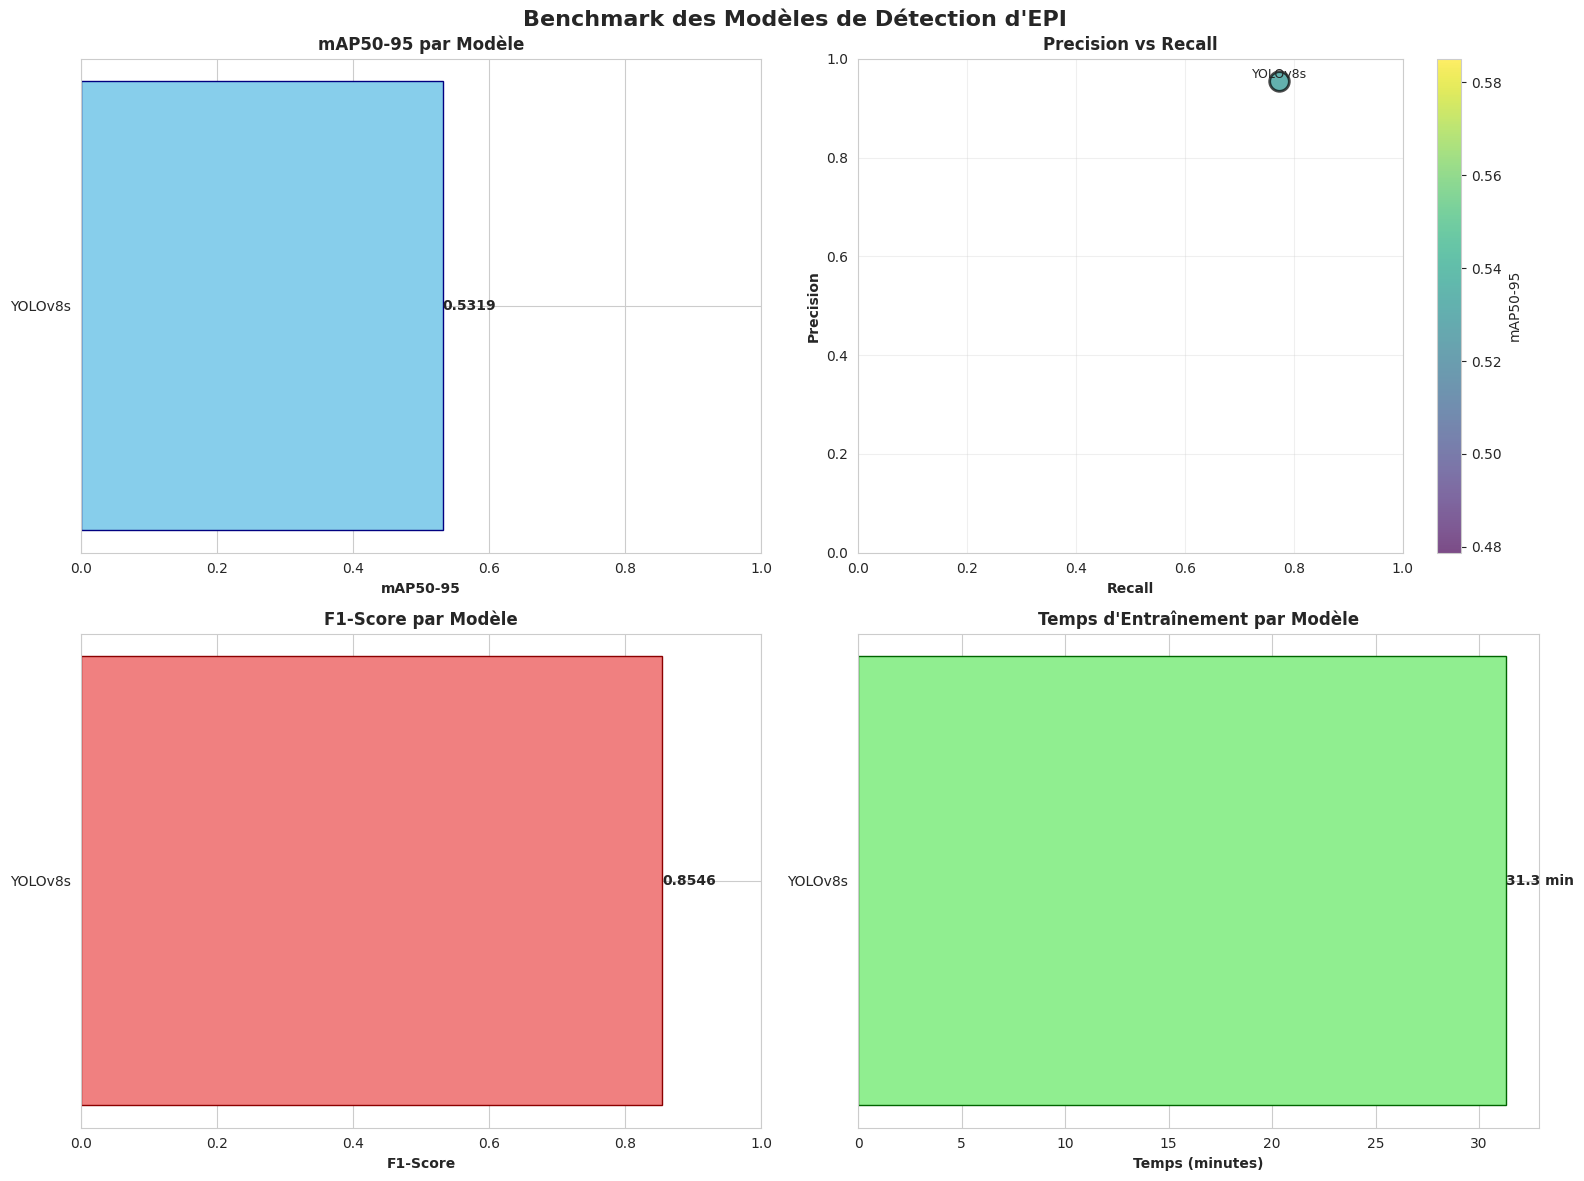

===== Radar chart sauvegardé: /content/drive/MyDrive/PFE-2026/Projet/V3/01/results/radar_chart.png=====


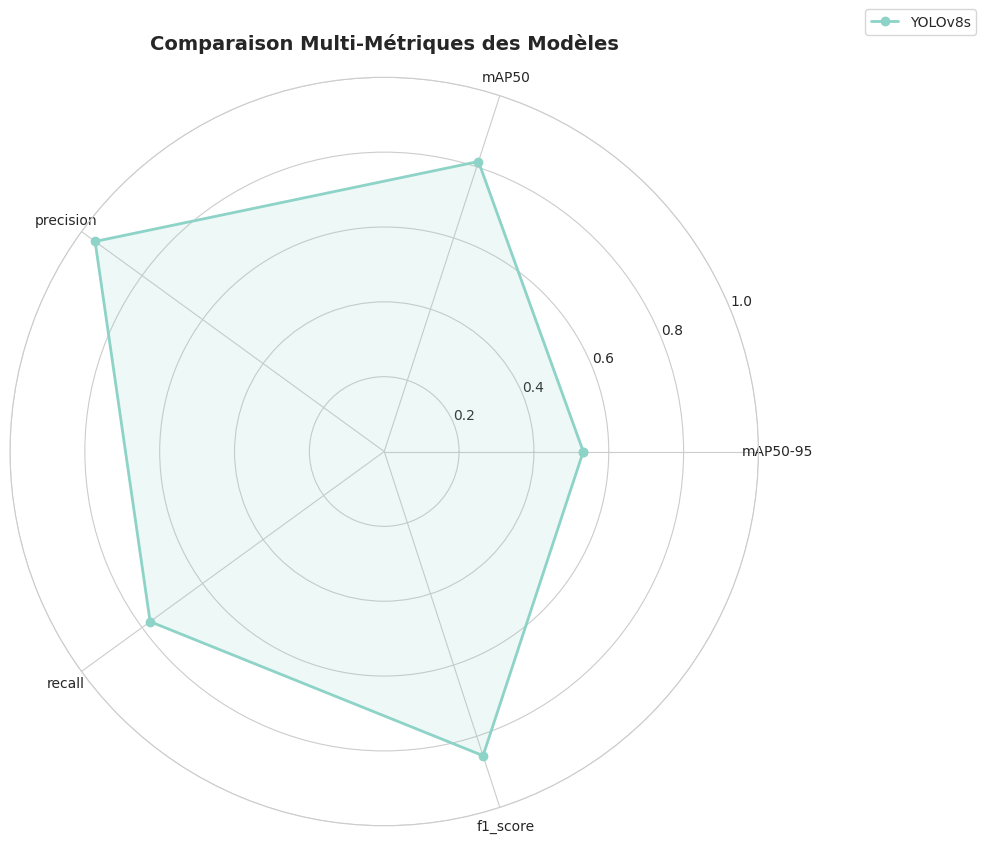


==== Tracé des courbes d'apprentissage pour YOLOv8s... ====
   Courbes d'apprentissage sauvegardées: /content/drive/MyDrive/PFE-2026/Projet/V3/01/results/YOLOv8s/learning_curves.png


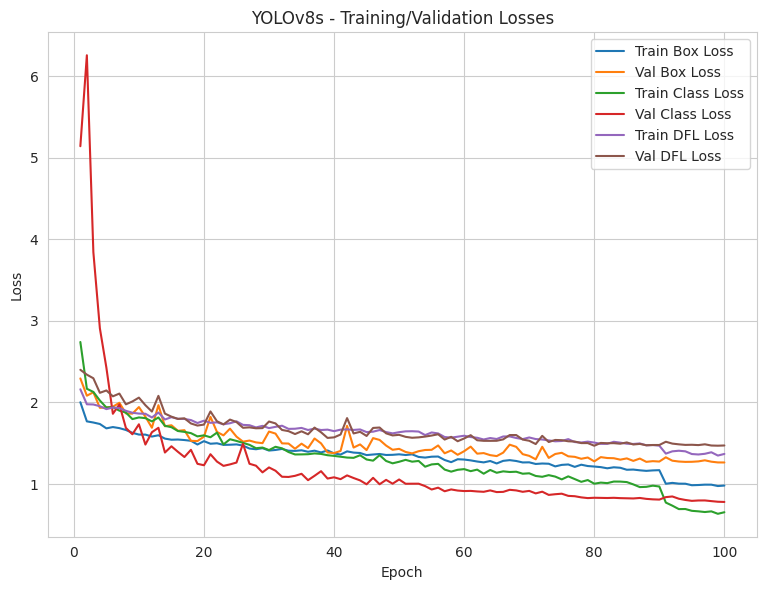

 ========ENTRAÎNEMENT ET BENCHMARK TERMINÉS AVEC SUCCÈS! ======
** Tous les résultats sont disponibles dans: /content/drive/MyDrive/PFE-2026/Projet/V3/01/results
** Modèles sauvegardés dans: /content/drive/MyDrive/PFE-2026/Projet/V3/01/models


In [20]:
if __name__ == "__main__":
    # Exécuter le pipeline complet
    results, benchmark_df = main()
